#  Skincare Product Recommendation — Machine Learning Project

**Dataset:** AI Skincare Personalization (Kaggle)  


##  Struktura e Projektit

| # | Seksioni |
|---|----------|
| 1 | Ngarkimi i bibliotekave dhe të dhënave |
| 2 | Parapërpunimi (Preprocessing) |
| 3 | Analiza Eksploratore (EDA) |
| 4 | Inxhinieria e Veçorive (Feature Engineering) |
| 5 | Klasifikimi — 5 modele + Hyperparameter Tuning |
| 6 | Rrjeta Neurale (MLP) — 2 arkitektura |
| 7 | Krahasimi i Modeleve |
| 8 | Grupimi (K-Means Clustering) |
| 9 | Konkluzionet Finale |

## 1. Ngarkimi i Bibliotekave dhe Të Dhënave

In [44]:
# Importojmë të gjitha bibliotekat e nevojshme
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & splitting
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.feature_selection import SelectKBest, f_classif

# Klasifikuesit
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Metrikat e vlerësimit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Clustering dhe reduktimi i dimensioneve
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Stilizimi i grafikave
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(" Bibliotekat u ngarkuan me sukses")

 Bibliotekat u ngarkuan me sukses


In [45]:
# Ngarkojmë të tre datasetet
users        = pd.read_csv('users.csv')
products     = pd.read_csv('skincare_100.csv')
interactions = pd.read_csv('interactions.csv')


if 'category' in products.columns and 'Category' not in products.columns:
    products = products.rename(columns={'category': 'Category'})


print(f"users.csv          → {users.shape[0]:>6,} rreshta  ×  {users.shape[1]} kolona")
print(f"skincare_100.csv   → {products.shape[0]:>6,} rreshta  ×  {products.shape[1]} kolona")
print(f"interactions.csv   → {interactions.shape[0]:>6,} rreshta  ×  {interactions.shape[1]} kolona")

users.csv          → 15,000 rreshta  ×  13 kolona
skincare_100.csv   →    100 rreshta  ×  7 kolona
interactions.csv   → 75,000 rreshta  ×  3 kolona


In [46]:
# Shikojmë disa shembuj nga secili dataset
print("── Shembuj nga Users ──")
display(users.head(3))

print("── Shembuj nga Products ──")
display(products.head(3))

print("── Shembuj nga Interactions ──")
display(interactions.head(3))

── Shembuj nga Users ──


,User_ID,Age,Skin_Type,Skin_Tone,Climate,Diet,Hormonal_Status,Budget_Level,Acne_Severity,Dryness_Severity,Pigmentation_Severity,Aging_Severity,Sensitivity_Severity
0,0,43,Sensitive,Medium,Humid,Vegan,Pregnant,High,0.000000,0.000000,0.000000,2.4,6.336962
1,1,29,Sensitive,Deep,Cold,Vegan,Teen,High,4.545657,3.589760,4.333578,0.0,7.976537
2,2,22,Dry,Medium,Humid,High_Dairy,Pregnant,High,0.000000,8.522342,0.000000,0.0,0.000000


── Shembuj nga Products ──


,id,Product_ID,name,Brand,Category,Price,Ingredients
0,0,453,BudgetBeauty Moisturizer,BudgetBeauty,Moisturizer,96,Retinol|Hyaluronic Acid|Ceramides
1,1,30,LuxuryGlow Moisturizer,LuxuryGlow,Moisturizer,140,Hyaluronic Acid
2,2,240,LuxuryGlow Moisturizer,LuxuryGlow,Moisturizer,125,Ceramides


── Shembuj nga Interactions ──


,User_ID,Product_ID,User_Rating
0,0,114,2.38
1,0,63,3.97
2,0,560,3.10


## 2. Parapërpunimi (Preprocessing)

Para çdo modelimi duhet të kuptojmë cilësinë e të dhënave:
- A ka vlera të munguara?
- Si duket shpërndarja e veçorive numerike?
- Si i trajtojmë kolonat speciale si `Ingredients`?

In [47]:
# Kontrollojmë vlerat e munguara në të tre datasetet
print("=== Vlerat e Munguara ===")
for name, df_ in [("users", users), ("products", products), ("interactions", interactions)]:
    missing = df_.isnull().sum().sum()
    print(f"  {name:>12}: {missing} vlerë të munguara")

=== Vlerat e Munguara ===
         users: 0 vlerë të munguara
      products: 0 vlerë të munguara
  interactions: 0 vlerë të munguara


In [48]:
# Statistika bazë për kolonat numerike
print("── Statistikat e Users (kolonat numerike) ──")
display(users.describe().round(2))

print("\n── Statistikat e Çmimeve të Produkteve ──")
display(products[['Price']].describe().round(2))

print("\n── Statistikat e Vlerësimeve ──")
display(interactions['User_Rating'].describe().round(2))

── Statistikat e Users (kolonat numerike) ──


,User_ID,Age,Acne_Severity,Dryness_Severity,Pigmentation_Severity,Aging_Severity,Sensitivity_Severity
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,7499.50,31.99,3.32,2.19,1.81,0.88,1.34
std,4330.27,10.00,3.27,3.19,2.27,1.32,2.66
min,0.00,15.00,0.00,0.00,0.00,0.00,0.00
25%,3749.75,23.00,0.00,0.00,0.00,0.00,0.00
50%,7499.50,32.00,2.86,0.00,0.00,0.00,0.00
75%,11249.25,40.00,5.53,3.47,4.13,1.50,0.00
max,14999.00,49.00,10.00,10.00,6.00,4.20,8.00



── Statistikat e Çmimeve të Produkteve ──


,Price
count,100.00
mean,75.27
std,41.30
min,11.00
25%,39.75
50%,70.50
75%,113.25
max,149.00



── Statistikat e Vlerësimeve ──


count    75000.00
mean         3.51
std          0.71
min          1.00
25%          3.03
50%          3.51
75%          4.00
max          5.00
Name: User_Rating, dtype: float64

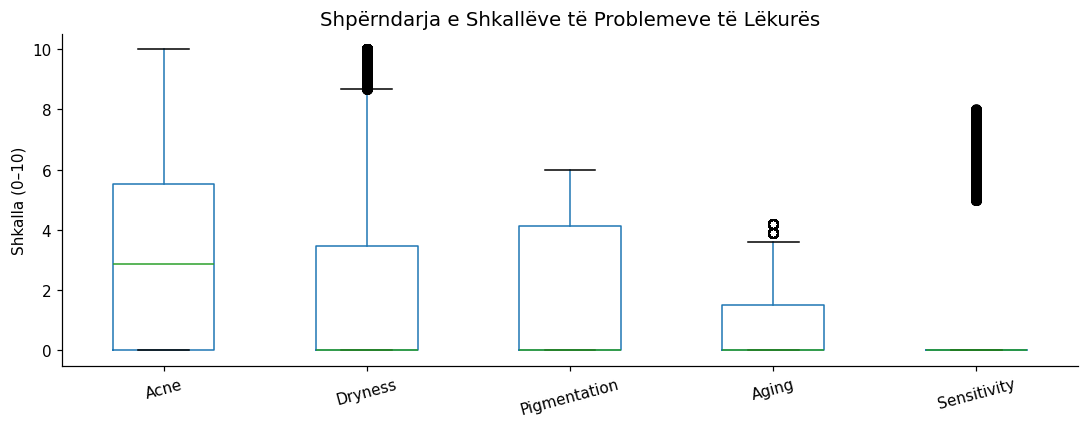

In [49]:
# Vizualizojmë shpërndarjen e problemeve të lëkurës me boxplot
# Boxplot tregon: mesataren, kuartilet dhe vlerat ekstreme (outliers)
severity_cols = ['Acne_Severity', 'Dryness_Severity',
                 'Pigmentation_Severity', 'Aging_Severity', 'Sensitivity_Severity']

fig, ax = plt.subplots(figsize=(10, 4))
users[severity_cols].boxplot(ax=ax, grid=False)
ax.set_title("Shpërndarja e Shkallëve të Problemeve të Lëkurës", fontsize=13)
ax.set_ylabel("Shkalla (0–10)")
ax.set_xticklabels([c.replace('_Severity', '') for c in severity_cols], rotation=15)
plt.tight_layout()
plt.show()


In [50]:
# Ndajmë kolonën Ingredients (e ndarë me '|') në listë ingredientësh
products['Ingredients'] = products['Ingredients'].str.split('|')

print("Shembull — kolona Ingredients pas ndarjes:")
display(products[['Product_ID', 'Brand', 'Price', 'Ingredients']].head(4))

Shembull — kolona Ingredients pas ndarjes:


,Product_ID,Brand,Price,Ingredients
0,453,BudgetBeauty,96,"[Retinol, Hyaluronic Acid, Ceramides]"
1,30,LuxuryGlow,140,[Hyaluronic Acid]
2,240,LuxuryGlow,125,[Ceramides]
3,366,ClinicalSkin,84,"[Ceramides, Retinol]"


In [51]:
# One-Hot Encoding i ingredientëve me MultiLabelBinarizer
# Çdo ingredient bëhet kolona e veçantë (0 ose 1)
mlb = MultiLabelBinarizer()
ing_matrix = mlb.fit_transform(products['Ingredients'])
ing_df = pd.DataFrame(ing_matrix, columns=[f"Ing_{c}" for c in mlb.classes_])
ing_df.insert(0, 'Product_ID', products['Product_ID'].values)

print("Ingredientët e gjetur:", list(mlb.classes_))
print(f"Dimensionet e matricës: {ing_df.shape}")
display(ing_df.head(3))

Ingredientët e gjetur: ['Ceramides', 'Hyaluronic Acid', 'Retinol', 'Salicylic Acid', 'Vitamin C']
Dimensionet e matricës: (100, 6)


,Product_ID,Ing_Ceramides,Ing_Hyaluronic Acid,Ing_Retinol,Ing_Salicylic Acid,Ing_Vitamin C
0,453,1,1,1,0,0
1,30,0,1,0,0,0
2,240,1,0,0,0,0


## 3. Analiza Eksploratore (EDA)

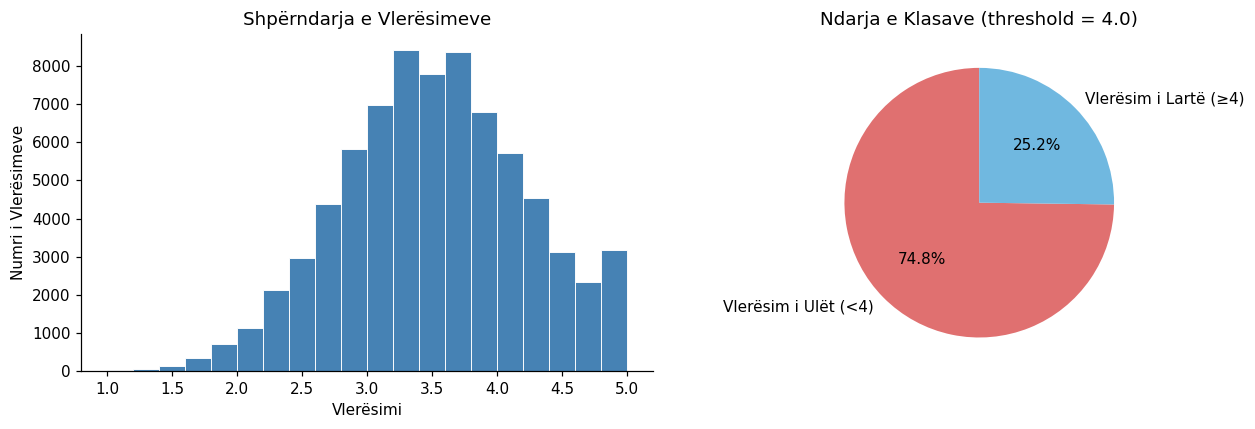

In [52]:
# Shpërndarja e vlerësimeve dhe ndarja e klasave binare
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram i vlerësimeve
axes[0].hist(interactions['User_Rating'], bins=20,
             color='steelblue', edgecolor='white', linewidth=0.6)
axes[0].set_title("Shpërndarja e Vlerësimeve")
axes[0].set_xlabel("Vlerësimi")
axes[0].set_ylabel("Numri i Vlerësimeve")

# Pie chart — klasa binare (≥4.0 = pozitiv, target-i ynë)
labels_count = (interactions['User_Rating'] >= 4.0).value_counts()
axes[1].pie(labels_count,
            labels=['Vlerësim i Ulët (<4)', 'Vlerësim i Lartë (≥4)'],
            autopct='%1.1f%%', colors=['#e07070', '#70b8e0'], startangle=90)
axes[1].set_title("Ndarja e Klasave (threshold = 4.0)")

plt.tight_layout()
plt.show()

pct_high = (interactions['User_Rating'] >= 4.0).mean() * 100

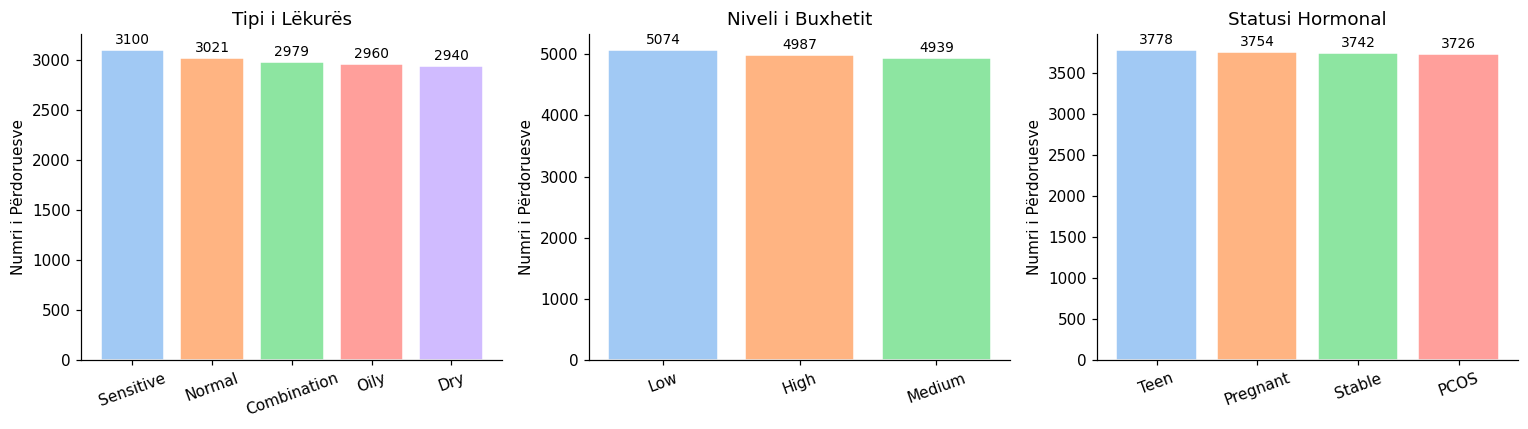

In [53]:
# Shpërndarja e tipit të lëkurës, buxhetit dhe statusit hormonal
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in zip(axes,
                           ['Skin_Type', 'Budget_Level', 'Hormonal_Status'],
                           ['Tipi i Lëkurës', 'Niveli i Buxhetit', 'Statusi Hormonal']):
    vc = users[col].value_counts()
    bars = ax.bar(vc.index, vc.values,
                  color=sns.color_palette("pastel"), edgecolor='white')
    ax.bar_label(bars, padding=2, fontsize=9)
    ax.set_title(title)
    ax.set_ylabel("Numri i Përdoruesve")
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

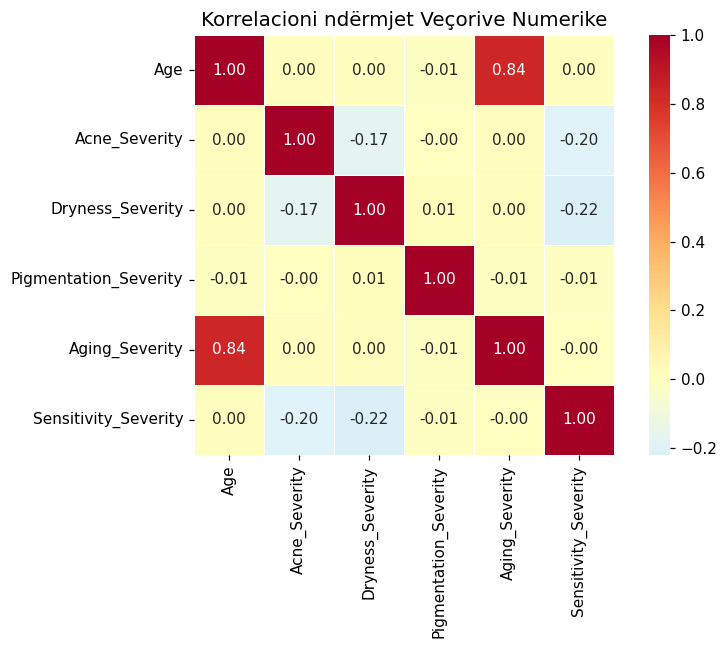

In [54]:
# Heatmap e korrelacionit ndërmjet veçorive numerike
numerical_cols = ['Age', 'Acne_Severity', 'Dryness_Severity',
                  'Pigmentation_Severity', 'Aging_Severity', 'Sensitivity_Severity']

corr_matrix = users[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Korrelacioni ndërmjet Veçorive Numerike", fontsize=13)
plt.tight_layout()
plt.show()

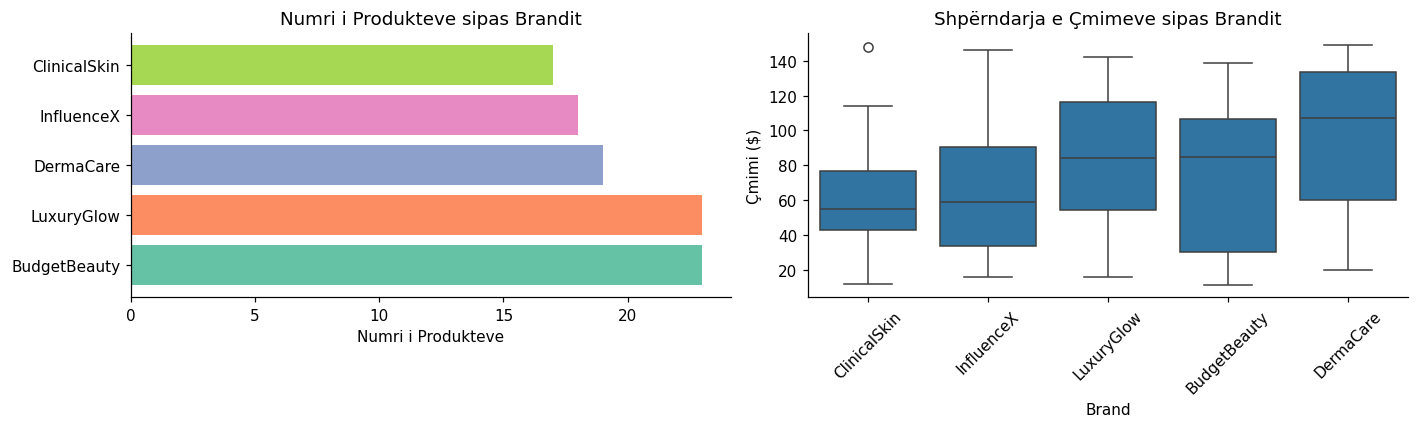

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Numri i produkteve sipas brandit
brand_counts = products['Brand'].value_counts()

axes[0].barh(
    brand_counts.index,
    brand_counts.values,
    color=sns.color_palette("Set2", len(brand_counts))
)
axes[0].set_title("Numri i Produkteve sipas Brandit")
axes[0].set_xlabel("Numri i Produkteve")

# Shpërndarja e çmimeve sipas brandit
brands_order = products.groupby('Brand')['Price'].median().sort_values().index

sns.boxplot(
    data=products,
    x='Brand',
    y='Price',
    order=brands_order,
    ax=axes[1]
)

axes[1].set_title("Shpërndarja e Çmimeve sipas Brandit")
axes[1].set_xlabel("Brand")
axes[1].set_ylabel("Çmimi ($)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

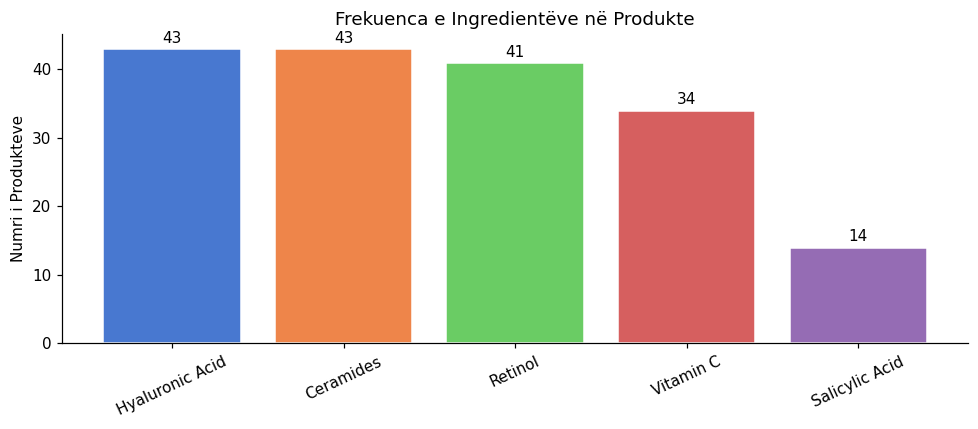

In [56]:
# Frekuenca e ingredientëve — cilët ingredientë gjenden më shpesh?
all_ingredients = [ing for sublist in products['Ingredients'] for ing in sublist]
ing_freq = Counter(all_ingredients).most_common()
labels, values = zip(*ing_freq)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, values, color=sns.color_palette("muted"), edgecolor='white')
ax.bar_label(bars, padding=2)
ax.set_title("Frekuenca e Ingredientëve në Produkte")
ax.set_ylabel("Numri i Produkteve")
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

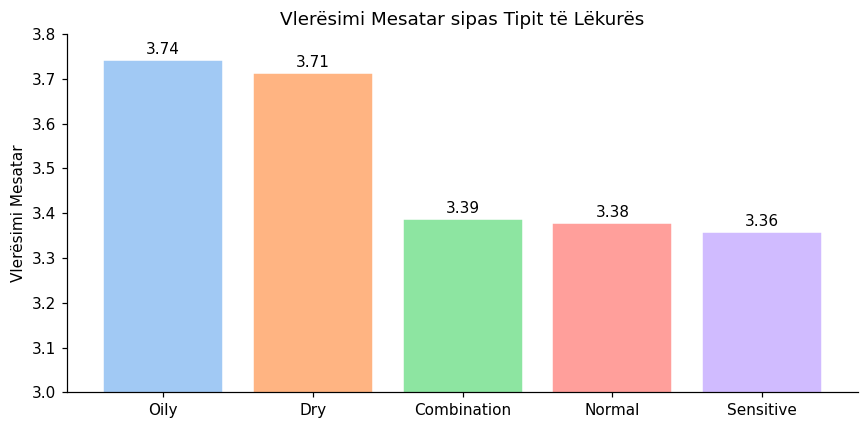

In [57]:
# Vlerësimi mesatar sipas tipit të lëkurës
merged_eda = interactions.merge(users[['User_ID', 'Skin_Type']], on='User_ID')
skin_rating = merged_eda.groupby('Skin_Type')['User_Rating'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(skin_rating.index, skin_rating.values,
              color=sns.color_palette("pastel"), edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=2)
ax.set_ylim(3.0, 3.8)
ax.set_title("Vlerësimi Mesatar sipas Tipit të Lëkurës")
ax.set_ylabel("Vlerësimi Mesatar")
plt.tight_layout()
plt.show()

## 4. Inxhinieria e Veçorive (Feature Engineering)

In [58]:
# Bashkojmë tabelat
df = interactions.merge(users, on='User_ID')

df = df.merge(
    products[['Product_ID', 'Brand', 'Price']],
    on='Product_ID'
)

df = df.merge(ing_df, on='Product_ID')

print(f"Dataset i bashkuar: {df.shape[0]:,} rreshta × {df.shape[1]} kolona")

display(df.head(3))

Dataset i bashkuar: 12,464 rreshta × 22 kolona


,User_ID,Product_ID,User_Rating,Age,Skin_Type,Skin_Tone,Climate,Diet,Hormonal_Status,Budget_Level,...,Pigmentation_Severity,Aging_Severity,Sensitivity_Severity,Brand,Price,Ing_Ceramides,Ing_Hyaluronic Acid,Ing_Retinol,Ing_Salicylic Acid,Ing_Vitamin C
0,1,168,3.80,29,Sensitive,Deep,Cold,Vegan,Teen,High,...,4.333578,0.0,7.976537,DermaCare,64,0,1,0,1,0
1,2,119,3.37,22,Dry,Medium,Humid,High_Dairy,Pregnant,High,...,0.000000,0.0,0.000000,LuxuryGlow,57,1,0,1,0,1
2,4,467,4.06,33,Sensitive,Deep,Temperate,High_Dairy,PCOS,Medium,...,3.929117,0.0,5.225884,BudgetBeauty,99,1,1,1,0,0


In [59]:
# Veçori bazuar në historinë e vlerësimeve të çdo përdoruesi
user_stats = interactions.groupby('User_ID')['User_Rating'].agg(
    user_mean_rating='mean',
    user_rating_std='std',
    user_interactions='count'
).reset_index()

# Nëse përdoruesi ka vetëm 1 vlerësim, devijimi standard është NaN → e zëvendësojmë me 0
user_stats['user_rating_std'] = user_stats['user_rating_std'].fillna(0)

df = df.merge(user_stats, on='User_ID')
print("Veçoritë e reja nga historia e përdoruesit: user_mean_rating, user_rating_std, user_interactions")

Veçoritë e reja nga historia e përdoruesit: user_mean_rating, user_rating_std, user_interactions


In [60]:
# Veçori bazuar në popullaritetin dhe vlerësimin mesatar të çdo produkti
product_stats = interactions.groupby('Product_ID')['User_Rating'].agg(
    product_mean_rating='mean',
    product_popularity='count'
).reset_index()

df = df.merge(product_stats, on='Product_ID')
print("Veçoritë e reja nga produkti: product_mean_rating, product_popularity")

Veçoritë e reja nga produkti: product_mean_rating, product_popularity


In [61]:
# Krijojmë target variable (etiketa):
# Vlerësim ≥ 4.0 → produkt i mirë (1), ndryshe → i keq (0)
df['label'] = (df['User_Rating'] >= 4.0).astype(int)

print("Shpërndarja e target-it:")
print(df['label'].value_counts().to_string())
print(f"\nRaporti i klasave: {df['label'].mean():.2%} pozitive (≥4.0)")

Shpërndarja e target-it:
label
0    9593
1    2871

Raporti i klasave: 23.03% pozitive (≥4.0)


In [62]:
# Kodojmë variablat kategorike me Label Encoding
# (konvertojmë tekst → numër, sepse modelet ML punojnë vetëm me numra)
cat_cols = ['Skin_Type', 'Skin_Tone', 'Climate', 'Diet', 'Hormonal_Status', 'Budget_Level', 'Brand']
encoders = {}

df_ml = df.copy()
for col in cat_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    encoders[col] = le  # ruajmë encoder-in për t'u përdorur më vonë

print("Kolonat:", cat_cols)

Kolonat: ['Skin_Type', 'Skin_Tone', 'Climate', 'Diet', 'Hormonal_Status', 'Budget_Level', 'Brand']


In [63]:
# Zgjedhim kolonat finale të veçorive (feature_cols)
ingredient_cols = [c for c in df_ml.columns if c.startswith('Ing_')]

feature_cols = (
    ['Age', 'Skin_Type', 'Skin_Tone', 'Climate', 'Diet', 'Hormonal_Status', 'Budget_Level',
     'Acne_Severity', 'Dryness_Severity', 'Pigmentation_Severity',
     'Aging_Severity', 'Sensitivity_Severity',
     'Brand', 'Price', 'product_mean_rating', 'product_popularity',
     'user_mean_rating', 'user_rating_std', 'user_interactions']
    + ingredient_cols
)

X = df_ml[feature_cols].values
y = df_ml['label'].values

print(f"Dimensionet e X (veçoritë): {X.shape}")
print(f"Numri total i veçorive: {len(feature_cols)}")

Dimensionet e X (veçoritë): (12464, 24)
Numri total i veçorive: 24


In [ ]:
# Ndajmë të dhënat: 80% për trajnim, 20% për testim
# RËNDËSI: Ndajmë PARA normalizimit për të shmangur data leakage
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalizojmë veçoritë (StandardScaler: mesatare=0, devijim=1)
# fit() vetëm mbi train — jo mbi test (ky është rregull i rëndësishëm!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f"Train: {X_train.shape[0]:,} shembuj  |  Test: {X_test.shape[0]:,} shembuj")
print(f"Klasa pozitive në train: {y_train.mean():.2%}  |  Në test: {y_test.mean():.2%}")